# Animating a UE Trajectory in a DeepMIMO Scenario

This notebook demonstrates how to use **NeoRadium** to animate a user equipment (UE) moving along a trajectory in a [DeepMIMO](https://www.deepmimo.net) scenario. It first opens a DeepMIMO scenario, creates a random trajectory, and then uses the [DeepMimoData.animateTrajectory](https://interdigitalinc.github.io/NeoRadium/html/source/API/DeepMIMO.html#neoradium.deepmimo.DeepMimoData.animateTrajectory) function to generate an animation of the UE movement on the map.

In addition to the animated trajectory, the notebook shows three time-varying quantities below the map:

1. **LOS/NLOS flag:** indicates whether the UE has a line-of-sight path to the base station at each trajectory point.
2. **First-path delay:** shows the delay of the first propagation path along the trajectory.
3. **First-path power:** shows the power, or path gain/loss, of the first propagation path along the trajectory.

The animation is created using a graph callback function. The callback is first called to configure the plots and is then called repeatedly during the animation to update the plot values as the UE moves from one trajectory point to the next.

### Notes

- The trajectory is generated from points on the DeepMIMO grid. The `trajLen` parameter refers to the number of DeepMIMO grid points used for the trajectory, not the final number of interpolated trajectory points. The full trajectory contains additional interpolated points between grid points.
- The plotted first-path delay and first-path power use the first available propagation path at each trajectory point.
- The user may need to update the `dataFolder` variable based on the location of the DeepMIMO scenario files on their system.
- The generated animation is saved as a GIF file and then displayed in the notebook.

In [1]:
import numpy as np
import matplotlib
from IPython.display import HTML, Markdown, display

from neoradium import DeepMimoData, BandwidthPart, random

In [2]:
# Replace this with the folder on your system where the DeepMIMO scenarios are stored
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (-164.55, 69.83, 1.50)
  No. of points:          7,984
  curIdx:                 0 (0.00%)
  curSpeed:               [10.64 10.64  0.  ]
  Total distance:         119.71 meters
  Total time:             7.983 seconds
  Average Speed:          14.996 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  6, 8.90, 10
  Totally blocked:        0
  LOS percentage:         48.58%



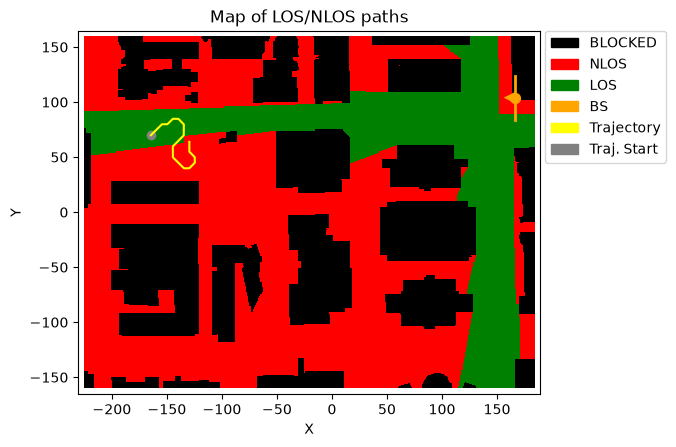

In [3]:
random.setSeed(123)                                 # Make results reproducible
bwp = BandwidthPart(numRbs=24, spacing=15)          # Create a BandwidthPart object

# Create a random trajectory
trajectory = deepMimoData.getRandomTrajectory(xyBounds=np.array([[-210, 40], [-120, 100]]),   # Trajectory bounds
                                              segLen=5,     # Number of DeepMIMO grid points on the shortest segment
                                              bwp=bwp,      # The bandwidth part
                                              trajLen=100,  # Number of DeepMIMO grid points on the trajectory
                                              speedMps=15)  # Speed in m/s

trajectory.print()                                  # Print the trajectory information
ax = deepMimoData.drawMap("LOS-NLOS", trajectory)   # Draw the map with the trajectory
deepMimoData.drawBsPanel(ax, 180)                   # TX antenna with a 180-degree bearing angle

In [4]:
# A callback function used to draw up to three graphs below the animated trajectory
def handleGraph(request, ax, trajectory, points=None):
    if request=="Config":
        # Configure all graphs
        ax[0].set_xlim(0,trajectory.numPoints)
        ax[0].set_ylim(0,1.2)
        ax[0].set_title("LOS/NLOS Flag")
        ax[0].grid()
        ax[0].plot([], [], color="green", markersize=1)     # Create empty plot for LOS/NLOS

        ax[1].set_xlim(0,trajectory.numPoints)
        ax[1].set_ylim(900,1700)
        ax[1].set_title("Delay of first path (ns)")
        ax[1].grid()
        ax[1].plot([], [], color="blue", markersize=1)      # Create empty plot for Delay

        ax[2].set_xlim(0,trajectory.numPoints)
        ax[2].set_ylim(-130,-80)
        ax[2].set_title("Power of first path (dB)")
        ax[2].grid()
        ax[2].plot([], [], color="red", markersize=1)       # Create empty plot for Power

    elif request=="Draw":
        # ax is an array of `numGraphs` elements
        p0, p1 = points
        return (ax[0].addNewPoint(p1, trajectory.points[p1].hasLos),
                ax[1].addNewPoint(p1, trajectory.points[p1].delays[0]),
                ax[2].addNewPoint(p1, trajectory.points[p1].powers[0]))
        
# Create the animation, save it as a GIF, and display it below.
anim = deepMimoData.animateTrajectory(trajectory, numGraphs=3, pointsPerFrame=20,
                                      graphCallback=handleGraph, fileName='AnimateTrj.gif',
                                      lastFrameDur=3000)
display(Markdown("![demo](AnimateTrj.gif)"))

# Another option is to use the following command which gives you more controls for running
# the animation.
#    # Increase the animation memory limit for HTML-based animation display
#    matplotlib.rcParams['animation.embed_limit'] = 100000000
#    HTML(anim.to_jshtml())

![demo](AnimateTrj.gif)